## Presentado por:

## Esteban Garcia Otalvaro
## Fabian Andres Posso

In [12]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal




**CONSTRUCCIÓN Y GRAFICACIÓN DE SEÑALES EN EL TIEMPO:**


a) Construya una señal cuadrada periódica, definiendo su frecuencia fundamental, amplitud y
número de muestras.


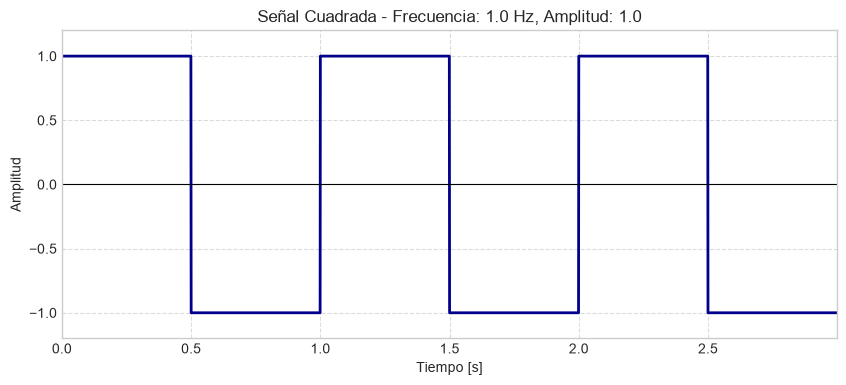

In [13]:
# 1. Parámetros definidos
f0 = 1.0           # Frecuencia fundamental (Hz)
T0 = 1.0 / f0      # Período fundamental (s)
A = 1.0            # Amplitud

# 2. Parámetros de muestreo (Ajustados para alta resolución)
fs = 1000.0        # Frecuencia de muestreo (Hz) - Alta para bordes definidos
N = 3000           # Número de muestras (3 segundos = 3 períodos exactos)

# 3. Construcción del vector de tiempo discreto
t = np.arange(N) / fs

# 4. Generación de la señal cuadrada
# signal.square genera una onda entre -1 y 1. Se multiplica por la amplitud 'A'.
senal_cuadrada = A * signal.square(2 * np.pi * f0 * t)

# 5. Visualización
plt.figure(figsize=(10, 4))
plt.plot(t, senal_cuadrada, color='darkblue', linewidth=2)
plt.title(f"Señal Cuadrada - Frecuencia: {f0} Hz, Amplitud: {A}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, max(t))
plt.ylim(-A * 1.2, A * 1.2)
plt.show()

b) Construya una señal triangular periódica, con la misma frecuencia fundamental, amplitud y
número de muestras que la señal anterior.

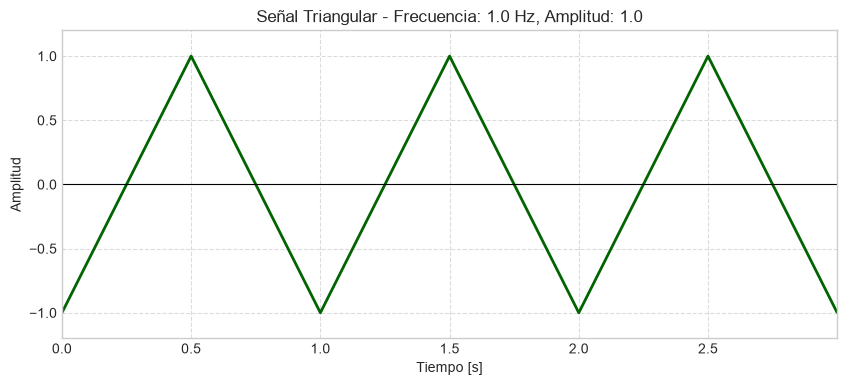

In [14]:
# 1. Parámetros idénticos a los de la señal cuadrada
f0 = 1.0           # Frecuencia fundamental (Hz)
A = 1.0            # Amplitud
fs = 1000.0        # Frecuencia de muestreo (Hz)
N = 3000           # Número de muestras (3 ciclos exactos)

# 2. Vector de tiempo
t = np.arange(N) / fs

# 3. Generación de la señal triangular
# signal.sawtooth genera una onda triangular simétrica cuando width=0.5
senal_triangular = A * signal.sawtooth(2 * np.pi * f0 * t, width=0.5)

# 4. Visualización
plt.figure(figsize=(10, 4))
plt.plot(t, senal_triangular, color='darkgreen', linewidth=2)
plt.title(f"Señal Triangular - Frecuencia: {f0} Hz, Amplitud: {A}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, max(t))
plt.ylim(-A * 1.2, A * 1.2)
plt.show()

c) Grafique ambas señales en el dominio del tiempo.

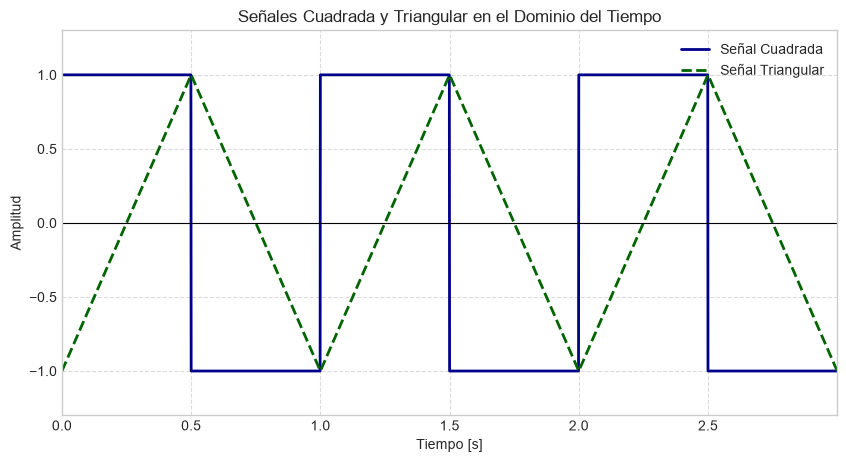

In [19]:
# 1. Visualización conjunta
plt.figure(figsize=(10, 5))

2# Trazado de ambas señales en los mismos ejes para comparar su alineación
plt.plot(t, senal_cuadrada, label='Señal Cuadrada', color='darkblue', linewidth=2)
plt.plot(t, senal_triangular, label='Señal Triangular', color='darkgreen', linewidth=2, linestyle='--')

plt.title("Señales Cuadrada y Triangular en el Dominio del Tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, max(t))
plt.ylim(-A * 1.3, A * 1.3)
plt.show()

d) Cree una función que reciba una señal periódica, y devuelva sus coeficientes de la serie de Fourier
(forma exponencial), calculados mediante NumPy.


In [28]:
# Se calculan los coeficientes para los armónicos desde -5 hasta 5
n_indices, c_n = coeficientes_fourier_exponencial(senal_cuadrada, t, f0=1.0, num_armonicos=5)

# Encabezado actualizado para incluir grados y radianes
print(f"{'Índice n':<10} | {'Magnitud':<10} | {'Fase (rad)':<12} | {'Fase (grados)':<12}")
print("-" * 55)

for idx, n_val in enumerate(n_indices):
    magnitud = np.abs(c_n[idx])
    
    # Filtrado numérico: Si la magnitud es prácticamente cero (armónicos pares),
    # forzamos la fase a 0 para limpiar el ruido de punto flotante.
    if magnitud < 1e-10:
        fase_rad = 0.0
    else:
        fase_rad = np.angle(c_n[idx])
        
    # Conversión a grados
    fase_deg = np.degrees(fase_rad)
    
    # Impresión sin la restricción de "n_val >= 0" para abarcar de -5 a 5
    print(f"n = {n_val:>2}    | {magnitud:<10.4f} | {fase_rad:<12.4f} | {fase_deg:<12.2f}°")


Índice n   | Magnitud   | Fase (rad)   | Fase (grados)
-------------------------------------------------------
n = -5    | 0.1273     | 1.5551       | 89.10       °
n = -4    | 0.0000     | 0.0000       | 0.00        °
n = -3    | 0.2122     | 1.5614       | 89.46       °
n = -2    | 0.0000     | 0.0000       | 0.00        °
n = -1    | 0.6366     | 1.5677       | 89.82       °
n =  0    | 0.0000     | 0.0000       | 0.00        °
n =  1    | 0.6366     | -1.5677      | -89.82      °
n =  2    | 0.0000     | 0.0000       | 0.00        °
n =  3    | 0.2122     | -1.5614      | -89.46      °
n =  4    | 0.0000     | 0.0000       | 0.00        °
n =  5    | 0.1273     | -1.5551      | -89.10      °


**APLICACIÓN DE LA FUNCIÓN obtener_coefientes_fourier(f) A LAS SEÑALES CUADRADA Y TRIANGULAR:**

e) Aplique la función anterior a la señal cuadrada y a la señal triangular, y obtenga sus respectivos
coeficientes

In [29]:
# 1. Definición de la resolución espectral
num_armonicos = 15

# 2. Estructuración de datos para procesamiento iterativo
senales = {
    "Cuadrada": senal_cuadrada,
    "Triangular": senal_triangular
}

# 3. Cálculo de coeficientes vectorizado mediante Dictionary Comprehension
coeficientes = {
    nombre: coeficientes_fourier_exponencial(senal, t, f0, num_armonicos) 
    for nombre, senal in senales.items()
}

# 4. Extracción de resultados
n_indices = coeficientes["Cuadrada"][0]
cn_cuadrada = coeficientes["Cuadrada"][1]
cn_triangular = coeficientes["Triangular"][1]

# 5. Formateo y visualización tabular (-5 a 5 con magnitudes y fases)
print(f"{'n':>3} | {'|Cn| Cuadrada':<13} | {'Fase Cuad (°)':<14} | {'|Cn| Triangular':<15} | {'Fase Tri (°)':<13}")
print("-" * 75)

# Filtrar para imprimir desde el armónico -5 hasta el 5
for i, n_val in enumerate(n_indices):
    if -5 <= n_val <= 5:
        # Magnitudes
        mag_cuad = np.abs(cn_cuadrada[i])
        mag_tri = np.abs(cn_triangular[i])
        
        # Filtrado de ruido y cálculo de fase en radianes
        fase_cuad_rad = 0.0 if mag_cuad < 1e-10 else np.angle(cn_cuadrada[i])
        fase_tri_rad = 0.0 if mag_tri < 1e-10 else np.angle(cn_triangular[i])
        
        # Conversión a grados
        fase_cuad_deg = np.degrees(fase_cuad_rad)
        fase_tri_deg = np.degrees(fase_tri_rad)
        
        # Limpieza visual de las magnitudes nulas (armónicos pares)
        if mag_cuad < 1e-10: mag_cuad = 0.0
        if mag_tri < 1e-10: mag_tri = 0.0
        
        # Impresión de la fila
        print(f"{n_val:>3} | {mag_cuad:<13.4f} | {fase_cuad_deg:<14.2f} | {mag_tri:<15.4f} | {fase_tri_deg:<13.2f}")


  n | |Cn| Cuadrada | Fase Cuad (°)  | |Cn| Triangular | Fase Tri (°) 
---------------------------------------------------------------------------
 -5 | 0.1273        | 89.10          | 0.0162          | 180.00       
 -4 | 0.0000        | 0.00           | 0.0000          | 0.00         
 -3 | 0.2122        | 89.46          | 0.0450          | 180.00       
 -2 | 0.0000        | 0.00           | 0.0000          | 0.00         
 -1 | 0.6366        | 89.82          | 0.4053          | 180.00       
  0 | 0.0000        | 0.00           | 0.0000          | 0.00         
  1 | 0.6366        | -89.82         | 0.4053          | -180.00      
  2 | 0.0000        | 0.00           | 0.0000          | 0.00         
  3 | 0.2122        | -89.46         | 0.0450          | -180.00      
  4 | 0.0000        | 0.00           | 0.0000          | 0.00         
  5 | 0.1273        | -89.10         | 0.0162          | -180.00      


f) Cree una función que reciba un conjunto de coeficientes de Fourier y grafique el espectro de
magnitud y el espectro de fase correspondientes.

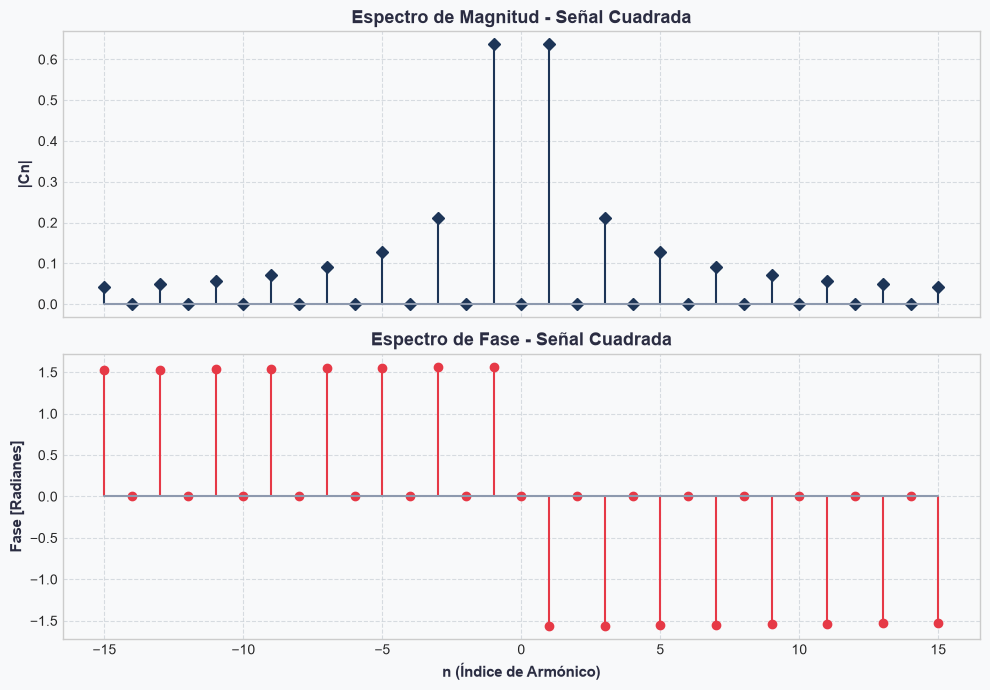

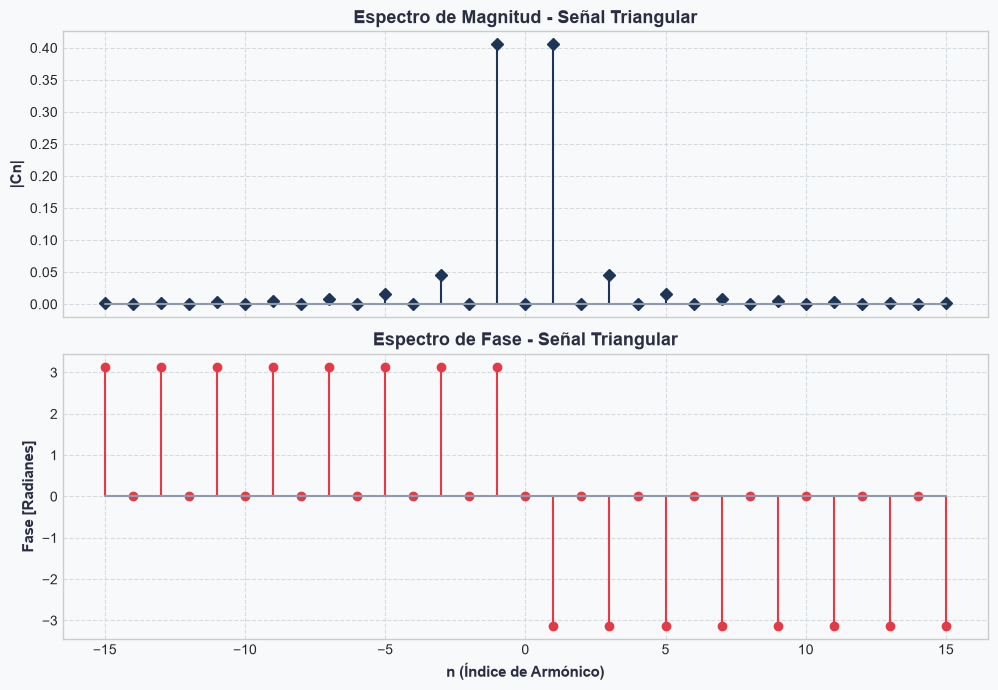

In [ ]:
def graficar_espectro(n, cn, titulo="Señal"):
    """
    Grafica los espectros discretos de magnitud y fase de una serie de Fourier.
    Incluye un filtro de umbral para suprimir ruido numérico en la fase.
    """
    # 1. Extracción de magnitud y fase
    magnitud = np.abs(cn)
    fase = np.angle(cn)
    
    # 2. Filtrado de ruido numérico (Optimización matemática)
    # Si la magnitud es prácticamente cero, forzamos la fase a 0 para evitar 
    # ángulos aleatorios generados por la imprecisión de punto flotante.
    fase[magnitud < 1e-10] = 0.0

    # 3. Configuración de la figura multipanel
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), facecolor='#F8F9FA', sharex=True)
    
    # 4. Espectro de Magnitud
    ax1.set_facecolor('#F8F9FA')
    ax1.stem(n, magnitud, linefmt="#571D4A", markerfmt='D', basefmt='#8D99AE')
    ax1.set_title(f"Espectro de Magnitud - {titulo}", fontsize=13, fontweight='bold', color="#2D3377")
    ax1.set_ylabel("|Cn|", fontsize=11, fontweight='bold', color='#2B2D42')
    ax1.grid(True, linestyle='--', color='#CED4DA', alpha=0.8)
    
    # 5. Espectro de Fase
    ax2.set_facecolor('#F8F9FA')
    ax2.stem(n, fase, linefmt='#E63946', markerfmt='o', basefmt='#8D99AE')
    ax2.set_title(f"Espectro de Fase - {titulo}", fontsize=13, fontweight='bold', color='#2B2D42')
    ax2.set_xlabel("n (Índice de Armónico)", fontsize=11, fontweight='bold', color='#2B2D42')
    ax2.set_ylabel("Fase [Radianes]", fontsize=11, fontweight='bold', color='#2B2D42')
    ax2.grid(True, linestyle='--', color='#CED4DA', alpha=0.8)
    
    # 6. Ajuste de márgenes y renderizado
    plt.tight_layout()
    plt.show()

# --- Comprobación: Ejecución de la función con las señales previas ---
graficar_espectro(n_indices, cn_cuadrada, titulo="Señal Cuadrada")
graficar_espectro(n_indices, cn_triangular, titulo="Señal Triangular")

g) Grafique los espectros de magnitud y fase de la señal cuadrada y de la señal triangular

Generando espectros para la Señal Cuadrada...


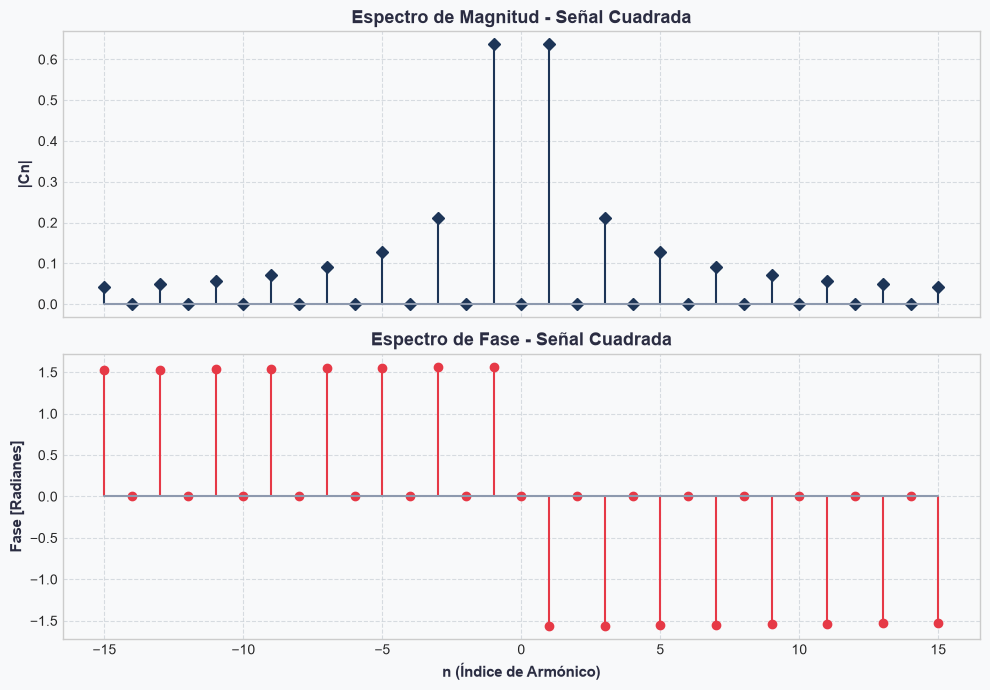

Generando espectros para la Señal Triangular...


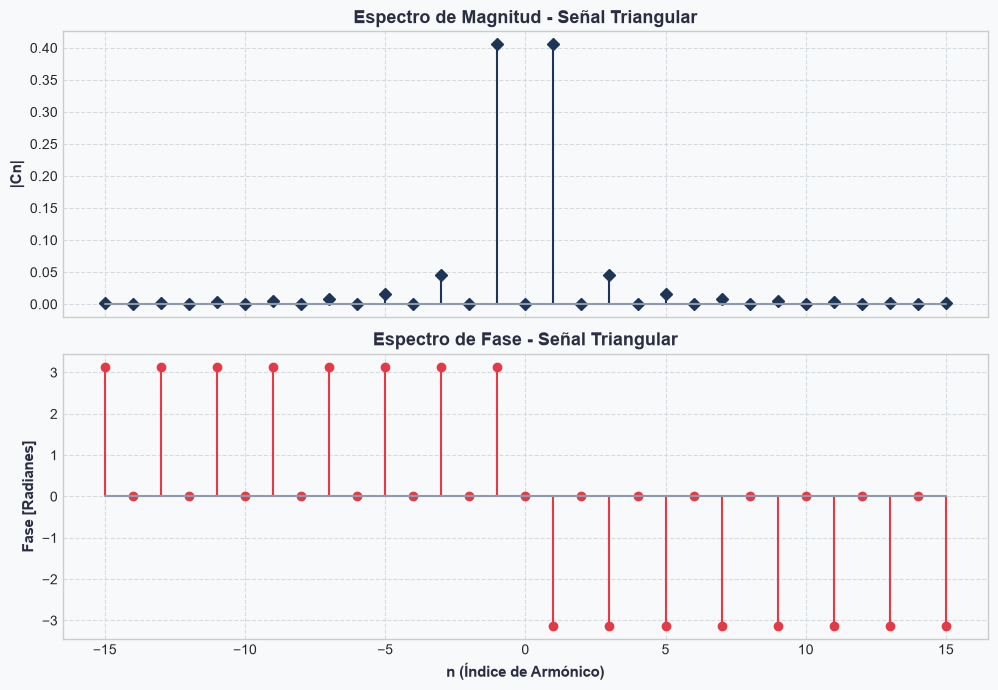

In [23]:
# Aplicación directa de la función creada en el inciso anterior
# Se asume que las variables n_indices, cn_cuadrada y cn_triangular ya están en memoria

print("Generando espectros para la Señal Cuadrada...")
graficar_espectro(n_indices, cn_cuadrada, titulo="Señal Cuadrada")

print("Generando espectros para la Señal Triangular...")
graficar_espectro(n_indices, cn_triangular, titulo="Señal Triangular")

h) Cree una función que reconstruya una señal a partir de una suma de senos (armónicos), recibiendo
como parámetros los coeficientes de Fourier y el número de armónicos a utilizar.

In [25]:
def reconstruir_senal(t, f0, n_indices, cn, num_armonicos):
    """
    Reconstruye una señal en el dominio del tiempo sumando un número específico de armónicos.
    Utiliza broadcasting matricial para evitar bucles for y optimizar el rendimiento.
    """
    # 1. Filtrado lógico (Máscara booleana)
    # Selecciona únicamente el componente DC (n=0) y los armónicos hasta el límite indicado
    mascara = np.abs(n_indices) <= num_armonicos
    n_usar = n_indices[mascara]
    cn_usar = cn[mascara]
    
    # 2. Reconstrucción vectorizada mediante la Identidad de Euler
    # Al expandir la exponencial compleja, se genera la suma de senos y cosenos implícita
    # matriz_fase tiene dimensiones (Armónicos, Muestras)
    matriz_fase = 1j * 2 * np.pi * f0 * n_usar[:, None] * t
    
    # 3. Sumatoria a lo largo del eje armónico (axis=0)
    # Se toma np.real() para descartar residuos imaginarios microscópicos (ruido de punto flotante)
    # originados durante las operaciones matriciales, garantizando una señal puramente real.
    senal_reconstruida = np.real(np.sum(cn_usar[:, None] * np.exp(matriz_fase), axis=0))
    
    return senal_reconstruida

**FUNCION PARA LA RECONSTRUCCIÓN PROGRESIVA DE LA SEÑAL CON SUS RESPECTIVAS GRAFICAS:**

i) Reconstruya la señal cuadrada y la señal triangular utilizando N = 1, 3, 5, 20 y 50 armónicos, y
grafique cada reconstrucción junto con la señal original.


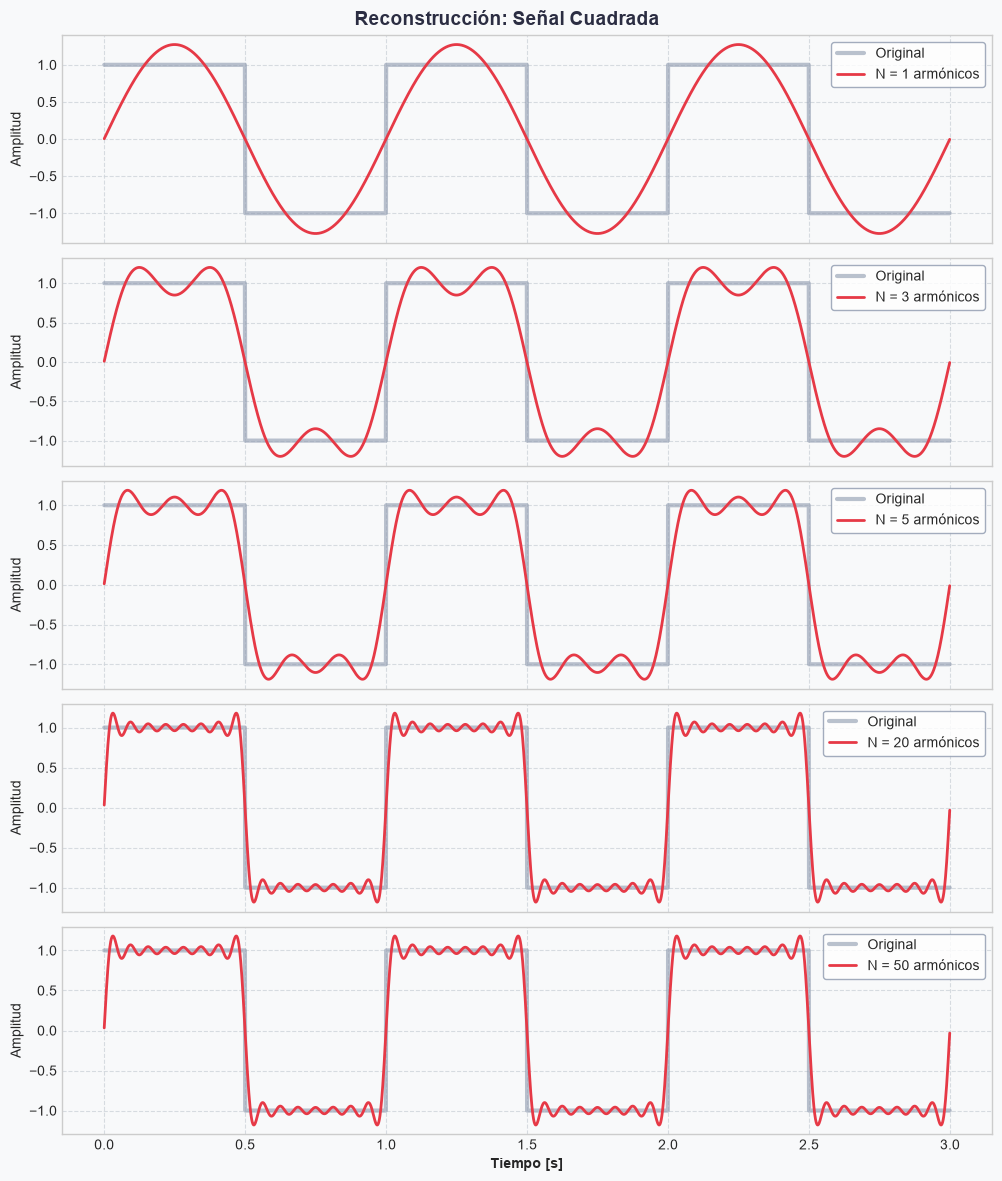

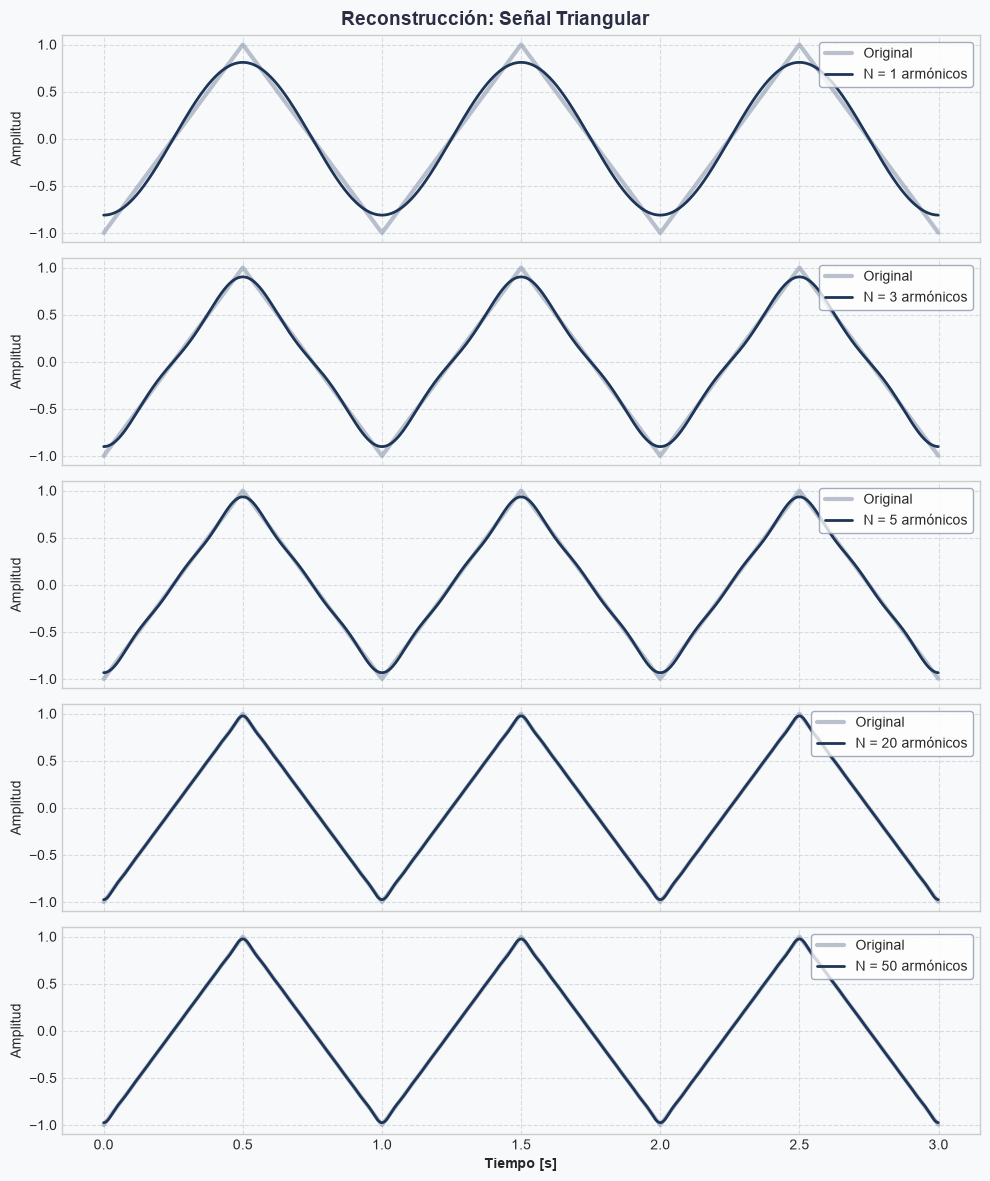

In [27]:
armonicos_evaluar = [1, 3, 5, 20, 50]

# 1. Reconstrucción y visualización de la Señal Cuadrada
fig_cuad, axes_cuad = plt.subplots(len(armonicos_evaluar), 1, figsize=(10, 12), sharex=True, facecolor='#F8F9FA')
fig_cuad.suptitle("Reconstrucción: Señal Cuadrada", fontsize=14, fontweight='bold', color='#2B2D42')

for ax, num_arm in zip(axes_cuad, armonicos_evaluar):
    ax.set_facecolor('#F8F9FA')
    # Llamada a la función vectorizada del inciso anterior
    senal_rec = reconstruir_senal(t, f0, n_indices, cn_cuadrada, num_arm)
    
    ax.plot(t, senal_cuadrada, color='#8D99AE', linewidth=3, label='Original', alpha=0.6)
    ax.plot(t, senal_rec, color='#E63946', linewidth=2, label=f'N = {num_arm} armónicos')
    
    ax.grid(True, linestyle='--', color='#CED4DA', alpha=0.8)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#8D99AE')
    ax.set_ylabel("Amplitud")

axes_cuad[-1].set_xlabel("Tiempo [s]", fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Reconstrucción y visualización de la Señal Triangular
fig_tri, axes_tri = plt.subplots(len(armonicos_evaluar), 1, figsize=(10, 12), sharex=True, facecolor='#F8F9FA')
fig_tri.suptitle("Reconstrucción: Señal Triangular", fontsize=14, fontweight='bold', color='#2B2D42')

for ax, num_arm in zip(axes_tri, armonicos_evaluar):
    ax.set_facecolor('#F8F9FA')
    # Llamada a la función vectorizada del inciso anterior
    senal_rec = reconstruir_senal(t, f0, n_indices, cn_triangular, num_arm)
    
    ax.plot(t, senal_triangular, color='#8D99AE', linewidth=3, label='Original', alpha=0.6)
    ax.plot(t, senal_rec, color='#1D3557', linewidth=2, label=f'N = {num_arm} armónicos')
    
    ax.grid(True, linestyle='--', color='#CED4DA', alpha=0.8)
    ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#8D99AE')
    ax.set_ylabel("Amplitud")

axes_tri[-1].set_xlabel("Tiempo [s]", fontweight='bold')
plt.tight_layout()
plt.show()

**COMPORTAMIENTO DEL FENOMENO DE GIBBS TANTO EN LA SEÑAL CUADRADA COMO EN LA TRIANGULAR:**

j) Consulte, analice y describa el fenómeno de Gibbs observado en las reconstrucciones de la señal
cuadrada

El Fenómeno de Gibbs ocurre cuando se aproxima una señal periódica mediante una serie truncada de Fourier si la señal contiene discontinuidades de salto (como los bordes verticales de la onda cuadrada).

A medida que se incrementa el número de armónicos $K$ ($K=1, 3, 5, 20, 50$), las oscilaciones de la señal reconstruida se comprimen hacia el punto de discontinuidad. Sin embargo, la magnitud del sobrepico o rizado cerca del salto no tiende a cero, sino que se estabiliza en aproximadamente un $8.95\%$ de la altura de la discontinuidad, es decir, sin importar cuántos millones de armónicos se agreguen a la Serie de Fourier de una señal con discontinuidades, la amplitud del primer sobrepico nunca desaparecerá; siempre se estabilizará exactamente en un $8.95\%$ de la altura del salto discontinuo (propiedad conocida como la Constante de Wilbraham-Gibbs).


En el contexto del procesamiento de bioseñales, como la electrocardiografía (ECG) o la electroencefalografía (EEG), el fenómeno de Gibbs cobra una relevancia clínica y técnica fundamental. Aunque las señales biológicas naturales rara vez presentan discontinuidades matemáticas perfectas como las de una onda cuadrada, sí contienen eventos transitorios de alta frecuencia y pendientes muy pronunciadas, como el complejo QRS en un electrocardiograma, los potenciales de acción neuromusculares o incluso los pulsos de calibración y espigas de marcapasos. Cuando estas bioseñales son sometidas a procesos de filtrado digital muy abruptos (por ejemplo, filtros pasa-bajas ideales o tipo "pared de ladrillo" para eliminar ruido electromagnético), el sistema está truncando o cortando radicalmente su espectro de frecuencias. Este corte abrupto equivale matemáticamente a usar un número finito de armónicos, lo que induce el fenómeno de Gibbs directamente sobre la bioseñal.

La consecuencia directa de este truncamiento espectral en la bioinstrumentación es la generación de artefactos de oscilación ("ringing") alrededor de los componentes rápidos de la bioseñal. En un entorno clínico, si el filtrado de un ECG genera un rizado de Gibbs alrededor del complejo QRS, estas oscilaciones artificiales pueden propagarse y distorsionar zonas críticas como el segmento ST o la onda T, llegando a simular muescas o alteraciones morfológicas que el paciente no tiene, lo cual podría derivar en un diagnóstico médico erróneo (como un falso positivo de isquemia o infarto). Por esta razón, al diseñar algoritmos para el procesamiento de bioseñales, los ingenieros evitan los cortes espectrales abruptos y prefieren utilizar filtros con transiciones más suaves (como Butterworth o Bessel) o aplicar ventanas de suavizado (como Hanning o Hamming), mitigando las oscilaciones de Gibbs para preservar la integridad de la morfología fisiológica.

**ANALISIS ESPECTRAL DE UNA SEÑAL ECG:**

k) Cargue una señal ECG sin ruido y su composición espectral. Consulte y describa brevemente los
componentes de frecuencia principales asociados a las ondas P, al complejo QRS y a la onda T.

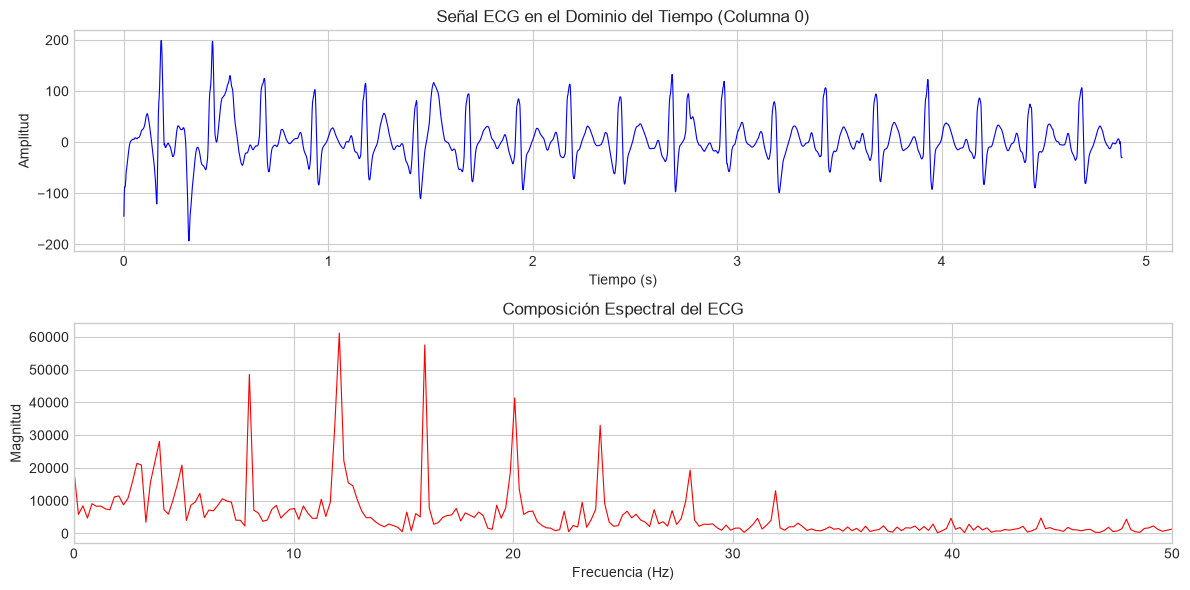

In [ ]:

# 1. Cargar el archivo CSV de la señal

archivo_csv = 'MUSE_20180111_155249_70000.csv'

df = pd.read_csv(archivo_csv, header=None)

# Definir la frecuencia de muestreo en Hz
fs = 1024  

# 2. Extraer la señal de ECG

indice_columna = 0 
senal_ecg = df.iloc[:, indice_columna].values

N = len(senal_ecg)
t = np.arange(N) / fs

# 3. Calcular la composición espectral (FFT)
frecuencias = np.fft.rfftfreq(N, 1/fs)
espectro_magnitud = np.abs(np.fft.rfft(senal_ecg))

# 4. Graficar la señal en el tiempo y su espectro
plt.figure(figsize=(12, 6))

# Gráfica en el dominio del tiempo
plt.subplot(2, 1, 1)
plt.plot(t, senal_ecg, color='blue', linewidth=0.8)
plt.title(f'Señal ECG en el Dominio del Tiempo (Columna {indice_columna})')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# Gráfica en el dominio de la frecuencia
plt.subplot(2, 1, 2)
plt.plot(frecuencias, espectro_magnitud, color='red', linewidth=0.8)
plt.title('Composición Espectral del ECG')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 50)  # Limitamos a 50 Hz para visualizar la energía útil del ECG
plt.grid(True)

plt.tight_layout()
plt.show()

La señal electrocardiográfica se compone de ondas asociadas a la despolarización y repolarización del tejido cardíaco, distribuidas en el dominio de la frecuencia de la siguiente forma:   

-Onda P: Corresponde a la despolarización auricular. Al tratarse de una onda de baja amplitud y con una pendiente suave y prolongada, sus componentes espectrales se concentran principalmente en las frecuencias bajas, ubicándose de manera predominante en el rango de 0.5 Hz a 10 Hz.

-Complejo QRS: Representa la despolarización ventricular. Debido a que es la deflexión más rápida, aguda y de mayor pendiente en el registro electrocardiográfico, contiene los componentes de mayor frecuencia de la señal cardíaca, concentrando su energía principal entre los 10 Hz y 40 Hz (pudiendo alcanzar hasta los 50 Hz).

-Onda T: Refleja la repolarización ventricular. Al igual que la onda P, es una onda de transición lenta y mayor duración temporal, por lo que su contenido de frecuencia es bajo y se sitúa principalmente entre 0.5 Hz y 10 Hz, dominando los componentes menores a 5 Hz.  